# Price history database

Sample code for connecting to the SQLite database written by
`download_ig_prices.ipynb`. The database path and the candle `RESOLUTION` to
view both come from `config.py`'s `Config` (`cfg.db_path`, `cfg.resolution`)
— the same `.env`-backed settings object the producer uses — so the two
notebooks agree on the file and table without repeating literals.

Each resolution gets its own table, named `candles_<suffix>` — `candles_1d`
for `DAY`, `candles_10min` for `MINUTE_10`, etc. The `resolution` ->
table-name mapping lives in `candle_db.py` (`table_name_for_resolution()`),
backed by `constants/resolutions.py` (`RESOLUTION_TABLE_SUFFIX`) — the same
module `download_ig_prices.ipynb` uses to create these tables. Each table
stores one OHLC candle per row:

| column | description |
| --- | --- |
| `epic` | instrument identifier, e.g. `IX.D.NASDAQ.IFA.IP` |
| `resolution` | candle resolution, e.g. `DAY` or `MINUTE_10` (redundant with the table name itself, kept for convenience) |
| `snapshot_time_utc` | candle timestamp, UTC, formatted ISO `YYYY-MM-DDTHH:MM:SS` |
| `{open,high,low,close}_{bid,ask,mid}_price`, `last_traded_volume` | flattened price columns (`constants/db_headers.py`'s `DB_HEADERS`), written by the producer via `candle_csv.candle_to_row()` — `mid` is `(bid + ask) / 2`, precomputed |
| `data` | the full raw IG candle JSON blob the flattened columns were built from: `openPrice` / `closePrice` / `highPrice` / `lowPrice` (each `{bid, ask, lastTraded}`) plus `lastTradedVolume` |

> The main path below uses only the Python standard library (`sqlite3`) and
> reads the flattened `*_mid_price` columns straight from the table (schema:
> `candle_db.init_candles_table()` / `constants/db_headers.py`'s `DB_HEADERS`).
> The raw `data` JSON blob is kept per row for anything those columns don't
> capture. The last section is an optional `pandas` view.

In [1]:
import sqlite3

from constants.ohlc_fields import OHLCField

In [2]:
# --- config: pulled from config.py (which loads .env), shared with the producer
from config import Config

cfg = Config.from_env()
RESOLUTION = cfg.resolution   # picks which candles_<suffix> table to read
DB_PATH = cfg.db_path         # same SQLite file download_ig_prices.ipynb writes
print(f"RESOLUTION = {RESOLUTION!r}")
print(f"DB_PATH    = {DB_PATH}")

RESOLUTION = 'DAY'
DB_PATH    = data\ig_market_data.db


In [3]:
assert DB_PATH.exists(), f"Database not found: {DB_PATH.resolve()}"

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row  # rows behave like dicts: row["epic"]

# What tables are in here?
[r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type = 'table'")]

['candles_1d']

In [4]:
# Inspect the schema and size of each table
for name, sql in conn.execute(
    "SELECT name, sql FROM sqlite_master WHERE type = 'table'"
):
    n = conn.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"{sql}\n  -> {n} rows\n")

CREATE TABLE candles_1d (
            epic              TEXT NOT NULL,
            resolution        TEXT NOT NULL,
            snapshot_time_utc TEXT NOT NULL,
            open_bid_price REAL,
            open_ask_price REAL,
            open_mid_price REAL,
            high_bid_price REAL,
            high_ask_price REAL,
            high_mid_price REAL,
            low_bid_price REAL,
            low_ask_price REAL,
            low_mid_price REAL,
            close_bid_price REAL,
            close_ask_price REAL,
            close_mid_price REAL,
            last_traded_volume INTEGER,
            data              TEXT NOT NULL,
            UNIQUE(epic, snapshot_time_utc)
        )
  -> 1768 rows



In [5]:
# Peek at a few rows from one resolution's table (flattened mid columns)
from candle_db import table_name_for_resolution

table = table_name_for_resolution(RESOLUTION)

for row in conn.execute(
    "SELECT epic, snapshot_time_utc, "
    "open_mid_price, high_mid_price, low_mid_price, close_mid_price, last_traded_volume "
    f"FROM {table} ORDER BY snapshot_time_utc LIMIT 3"
):
    print(dict(row))

{'epic': 'IX.D.NASDAQ.IFA.IP', 'snapshot_time_utc': '2020-12-30T13:00:00', 'open_mid_price': 12894.2, 'high_mid_price': 12913.4, 'low_mid_price': 12826.7, 'close_mid_price': 12861.1, 'last_traded_volume': 312275}
{'epic': 'IX.D.NASDAQ.IFA.IP', 'snapshot_time_utc': '2020-12-31T13:00:00', 'open_mid_price': 12860.6, 'high_mid_price': 12902.0, 'low_mid_price': 12804.2, 'close_mid_price': 12889.5, 'last_traded_volume': 247713}
{'epic': 'IX.D.NASDAQ.IFA.IP', 'snapshot_time_utc': '2021-01-03T13:00:00', 'open_mid_price': 12908.2, 'high_mid_price': 12964.6, 'low_mid_price': 12830.5, 'close_mid_price': 12957.5, 'last_traded_volume': 78873}


## Load flat OHLC rows

`candle_db.load_candles(conn, resolution, epic=None)` reads the flattened
`*_mid_price` columns (no JSON parsing) and yields one dict per candle,
oldest first — `open`/`high`/`low`/`close` plus explicit `*_mid_price`
aliases, `volume`, and `epic` / `resolution` / `snapshot_time_utc`.

In [6]:
from candle_db import load_candles

candles = list(load_candles(conn, RESOLUTION))
print(f"{len(candles)} candles")
for c in candles[:5]:
    print(c)

1768 candles
{'epic': 'IX.D.NASDAQ.IFA.IP', 'resolution': 'DAY', 'snapshot_time_utc': '2020-12-30T13:00:00', 'open': 12894.2, 'high': 12913.4, 'low': 12826.7, 'close': 12861.1, 'open_mid_price': 12894.2, 'high_mid_price': 12913.4, 'low_mid_price': 12826.7, 'close_mid_price': 12861.1, 'volume': 312275}
{'epic': 'IX.D.NASDAQ.IFA.IP', 'resolution': 'DAY', 'snapshot_time_utc': '2020-12-31T13:00:00', 'open': 12860.6, 'high': 12902.0, 'low': 12804.2, 'close': 12889.5, 'open_mid_price': 12860.6, 'high_mid_price': 12902.0, 'low_mid_price': 12804.2, 'close_mid_price': 12889.5, 'volume': 247713}
{'epic': 'IX.D.NASDAQ.IFA.IP', 'resolution': 'DAY', 'snapshot_time_utc': '2021-01-03T13:00:00', 'open': 12908.2, 'high': 12964.6, 'low': 12830.5, 'close': 12957.5, 'open_mid_price': 12908.2, 'high_mid_price': 12964.6, 'low_mid_price': 12830.5, 'close_mid_price': 12957.5, 'volume': 78873}
{'epic': 'IX.D.NASDAQ.IFA.IP', 'resolution': 'DAY', 'snapshot_time_utc': '2021-01-04T13:00:00', 'open': 12956.6, 'high

## pandas DataFrame

`pandas` is not required for anything above. Run the install cell once if you want it.

In [7]:
try:
    import pandas as pd
except ModuleNotFoundError:
    print("pandas not installed - run:  %pip install pandas")
    df = None
else:
    df = pd.DataFrame(load_candles(conn, RESOLUTION))
    df[OHLCField.SNAPSHOT_TIME_UTC] = pd.to_datetime(
        df[OHLCField.SNAPSHOT_TIME_UTC], format="%Y-%m-%dT%H:%M:%S"
    )
    df = df.set_index(OHLCField.SNAPSHOT_TIME_UTC)
    display(df)

,epic,resolution,open,high,low,close,open_mid_price,high_mid_price,low_mid_price,close_mid_price,volume
snapshot_time_utc,,,,,,,,,,,
2020-12-30 13:00:00,IX.D.NASDAQ.IFA.IP,DAY,12894.20,12913.4,12826.7,12861.1,12894.20,12913.4,12826.7,12861.1,312275
2020-12-31 13:00:00,IX.D.NASDAQ.IFA.IP,DAY,12860.60,12902.0,12804.2,12889.5,12860.60,12902.0,12804.2,12889.5,247713
2021-01-03 13:00:00,IX.D.NASDAQ.IFA.IP,DAY,12908.20,12964.6,12830.5,12957.5,12908.20,12964.6,12830.5,12957.5,78873
2021-01-04 13:00:00,IX.D.NASDAQ.IFA.IP,DAY,12956.60,12958.6,12529.7,12689.7,12956.60,12958.6,12529.7,12689.7,651215
2021-01-05 13:00:00,IX.D.NASDAQ.IFA.IP,DAY,12689.20,12853.9,12501.6,12599.4,12689.20,12853.9,12501.6,12599.4,596853
...,...,...,...,...,...,...,...,...,...,...,...
2026-08-31 14:00:00,IX.D.NASDAQ.IFA.IP,DAY,29384.45,29518.6,28988.4,29052.5,29384.45,29518.6,28988.4,29052.5,477062
2026-09-01 14:00:00,IX.D.NASDAQ.IFA.IP,DAY,29052.90,29267.9,28878.4,29012.7,29052.90,29267.9,28878.4,29012.7,514177
2026-09-02 14:00:00,IX.D.NASDAQ.IFA.IP,DAY,29012.30,29331.0,28984.3,29288.7,29012.30,29331.0,28984.3,29288.7,469464


In [8]:
# Done reading from SQLite - release the connection (the chart below only needs `df`)
conn.close()

## OHLC candlestick chart with volume

Drawn with matplotlib primitives only (no `mplfinance`): a high&ndash;low wick plus an
open&ndash;close body per candle, green when `close >= open` else red, with a volume
panel sharing the x-axis. This is the final cell &mdash; running the notebook top to
bottom ends here.

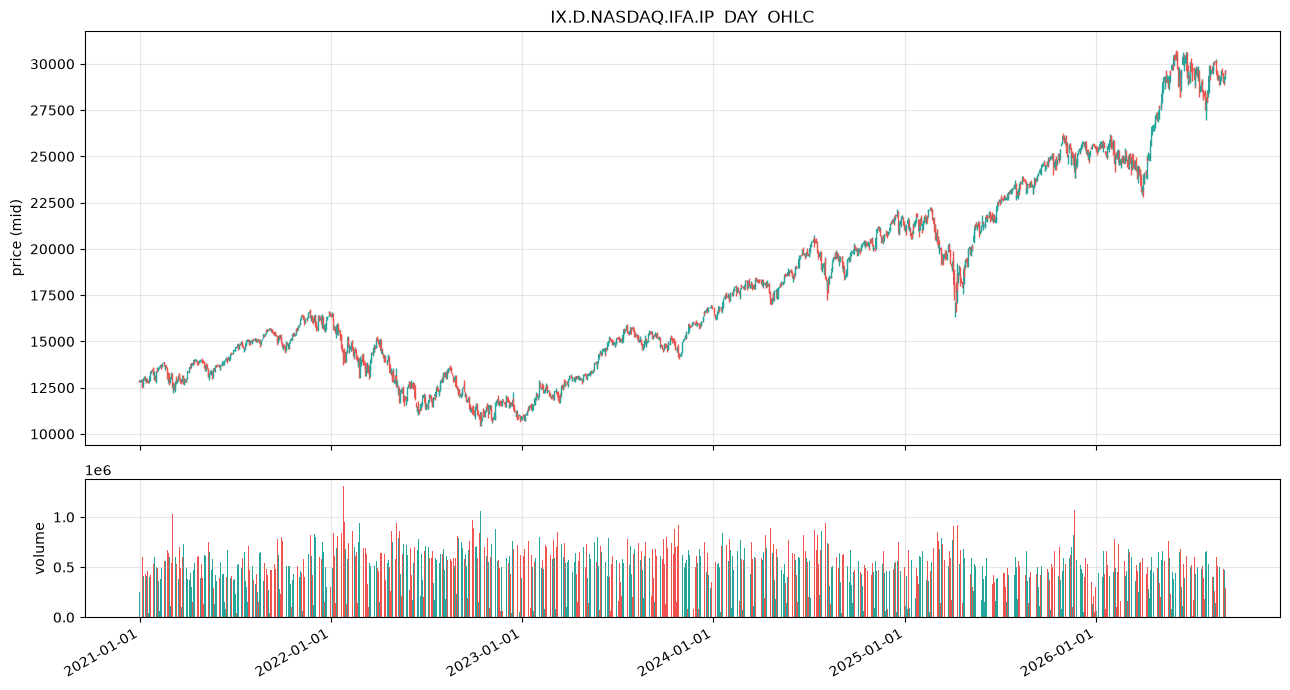

In [9]:
if df is None:
    print("Run the pandas cell above first (needs pandas installed).")
else:
    try:
        import matplotlib.dates as mdates
        import matplotlib.pyplot as plt
    except ModuleNotFoundError:
        print("matplotlib not installed - run:  %pip install matplotlib")
    else:
        ohlc = df.sort_index()

        up = ohlc[OHLCField.CLOSE] >= ohlc[OHLCField.OPEN]
        color = up.map({True: "#26a69a", False: "#ef5350"})

        # candle width = 80% of the median bar interval, in matplotlib date units (days)
        step = ohlc.index.to_series().diff().median()
        width = step.total_seconds() / 86400 * 0.8 if pd.notna(step) else 6e-4

        fig, (ax_price, ax_vol) = plt.subplots(
            2, 1, sharex=True, figsize=(13, 7),
            gridspec_kw={"height_ratios": [3, 1]},
        )

        # price: high-low wick, then open-close body
        ax_price.vlines(ohlc.index, ohlc[OHLCField.LOW], ohlc[OHLCField.HIGH], color=color, linewidth=1)
        ax_price.bar(
            ohlc.index,
            (ohlc[OHLCField.CLOSE] - ohlc[OHLCField.OPEN]).abs(),
            bottom=ohlc[[OHLCField.OPEN, OHLCField.CLOSE]].min(axis=1),
            width=width,
            color=color,
        )
        ax_price.set_ylabel("price (mid)")
        ax_price.set_title(f"{ohlc[OHLCField.EPIC].iat[0]}  {ohlc[OHLCField.RESOLUTION].iat[0]}  OHLC")
        ax_price.grid(alpha=0.3)

        # volume
        ax_vol.bar(ohlc.index, ohlc[OHLCField.VOLUME], width=width, color=color)
        ax_vol.set_ylabel("volume")
        ax_vol.grid(alpha=0.3)

        ax_vol.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax_vol.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()